<a href="https://colab.research.google.com/github/Muqtarali/Machine-Learning/blob/main/Ensemble%20Learning/Bagging/Bagging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/Iris.csv")

In [ ]:
df = df.iloc[:,1:]
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['Species'] = encoder.fit_transform(df['Species'])
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
df = df[df['Species'] != 0][['SepalWidthCm','PetalLengthCm','Species']]
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


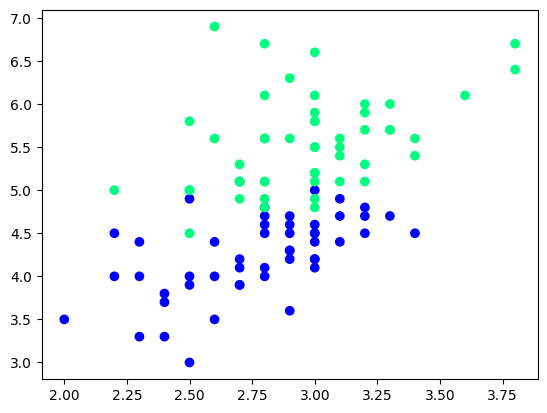

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [ ]:
df_train = df.iloc[:60,:].sample(10)
df_train

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
52,3.1,4.9,1
53,2.3,4.0,1
75,3.0,4.4,1
86,3.1,4.7,1
82,2.7,3.9,1
99,2.8,4.1,1
100,3.3,6.0,2
63,2.9,4.7,1
109,3.6,6.1,2


In [ ]:
# Taking only 10 rows for training
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [ ]:
df_train

,SepalWidthCm,PetalLengthCm,Species
71,2.8,4.0,1
52,3.1,4.9,1
53,2.3,4.0,1
75,3.0,4.4,1
86,3.1,4.7,1
82,2.7,3.9,1
99,2.8,4.1,1
100,3.3,6.0,2
63,2.9,4.7,1
109,3.6,6.1,2


In [ ]:
df_val

,SepalWidthCm,PetalLengthCm,Species
114,2.8,5.1,2
147,3.0,5.2,2
133,2.8,5.1,2
104,3.0,5.8,2
86,3.1,4.7,1


In [ ]:
df_test

,SepalWidthCm,PetalLengthCm,Species
117,3.8,6.7,2
105,3.0,6.6,2
62,2.2,4.0,1
126,2.8,4.8,2
93,2.3,3.3,1


In [ ]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [ ]:

X_test

array([[2.8, 5.1],
       [3. , 5.2],
       [2.8, 5.1],
       [3. , 5.8],
       [3.1, 4.7]])

# **Bagging**

In [ ]:
 # Data for Tree 1
df_bag = df_train.sample(8,replace=True)

X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
118,2.6,6.9,2
85,3.4,4.5,1
91,3.0,4.6,1
79,2.6,3.5,1
136,3.4,5.6,2
91,3.0,4.6,1
92,2.6,4.0,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score
dt_bag1 = DecisionTreeClassifier()


In [ ]:
def evaluate(clf,X,y):
    clf.fit(X,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    y_pred = clf.predict(X_test)
    print(accuracy_score(y_test,y_pred))

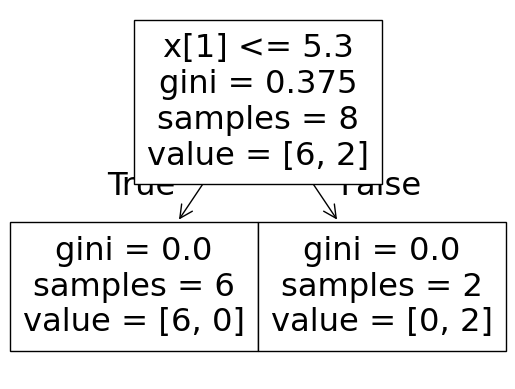

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


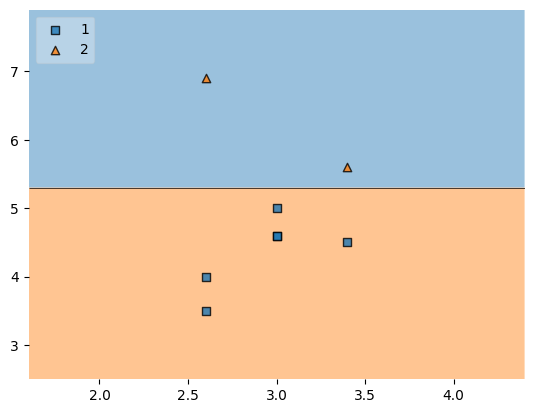

In [ ]:
evaluate(dt_bag1,X,y)

In [ ]:

# Data for Tree 2
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
78,2.9,4.5,1
66,3.0,4.5,1
85,3.4,4.5,1
136,3.4,5.6,2
92,2.6,4.0,1
118,2.6,6.9,2
79,2.6,3.5,1
77,3.0,5.0,1


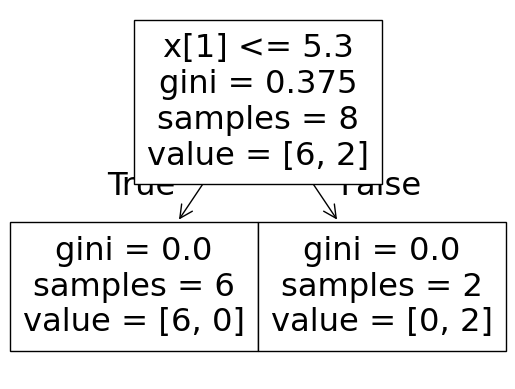

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


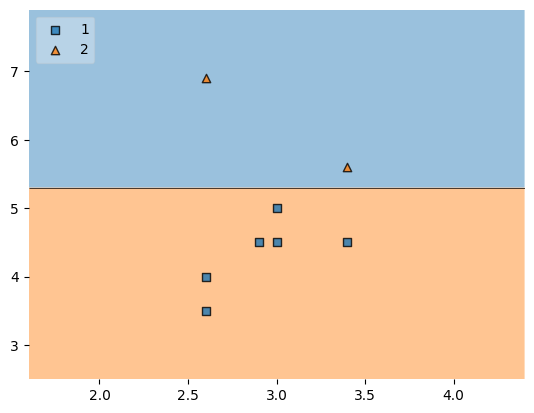

In [ ]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2,X,y)

In [ ]:

# Data for Tree 3
df_bag = df_train.sample(8,replace=True)

# Fetch X and y
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

# print df_bag
df_bag

,SepalWidthCm,PetalLengthCm,Species
92,2.6,4.0,1
136,3.4,5.6,2
77,3.0,5.0,1
79,2.6,3.5,1
136,3.4,5.6,2
118,2.6,6.9,2
118,2.6,6.9,2
77,3.0,5.0,1


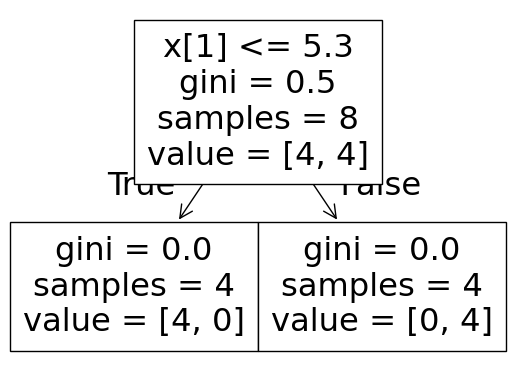

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


0.4


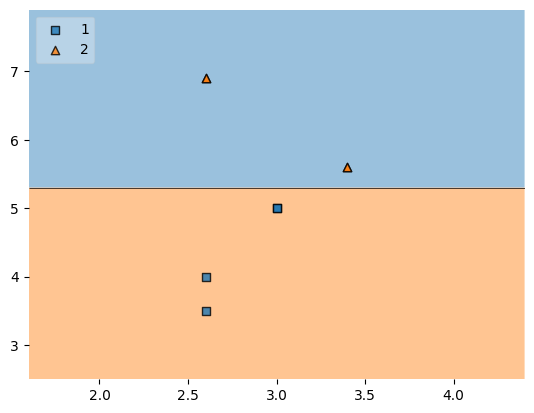

In [ ]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3,X,y)


# **Predict**

In [ ]:
df_test

,SepalWidthCm,PetalLengthCm,Species
117,3.8,6.7,2
105,3.0,6.6,2
62,2.2,4.0,1
126,2.8,4.8,2
93,2.3,3.3,1


In [ ]:
print("Predictor 1",dt_bag1.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 2",dt_bag2.predict(np.array([2.2,5.0]).reshape(1,2)))
print("Predictor 3",dt_bag3.predict(np.array([2.2,5.0]).reshape(1,2)))

Predictor 1 [1]
Predictor 2 [1]
Predictor 3 [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [ ]:

# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
118,2.6,6.9,2
85,3.4,4.5,1
78,2.9,4.5,1
77,3.0,5.0,1
122,2.8,6.7,2
92,2.6,4.0,1
136,3.4,5.6,2
79,2.6,3.5,1
66,3.0,4.5,1


In [ ]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
77,3.0,5.0,1
79,2.6,3.5,1
66,3.0,4.5,1
136,3.4,5.6,2
122,2.8,6.7,2
85,3.4,4.5,1
118,2.6,6.9,2
78,2.9,4.5,1


# **Pasting**

In [ ]:
# Row sampling without replacement
df_train

,SepalWidthCm,PetalLengthCm,Species
91,3.0,4.6,1
118,2.6,6.9,2
85,3.4,4.5,1
78,2.9,4.5,1
77,3.0,5.0,1
122,2.8,6.7,2
92,2.6,4.0,1
136,3.4,5.6,2
79,2.6,3.5,1
66,3.0,4.5,1


In [ ]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
85,3.4,4.5,1
92,2.6,4.0,1
122,2.8,6.7,2
118,2.6,6.9,2
91,3.0,4.6,1
136,3.4,5.6,2
78,2.9,4.5,1
79,2.6,3.5,1



# Random **Subspaces**

In [ ]:

df1 = pd.read_csv('/content/Iris.csv')
df1 = df1.sample(10)
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
99,100,5.7,2.8,4.1,1.3,Iris-versicolor
113,114,5.7,2.5,5.0,2.0,Iris-virginica
121,122,5.6,2.8,4.9,2.0,Iris-virginica
44,45,5.1,3.8,1.9,0.4,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
89,90,5.5,2.5,4.0,1.3,Iris-versicolor
25,26,5.0,3.0,1.6,0.2,Iris-setosa
120,121,6.9,3.2,5.7,2.3,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
136,137,6.3,3.4,5.6,2.4,Iris-virginica



Random **Patches**

In [ ]:

df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
99,100,5.7,2.8,4.1,1.3,Iris-versicolor
113,114,5.7,2.5,5.0,2.0,Iris-virginica
121,122,5.6,2.8,4.9,2.0,Iris-virginica
44,45,5.1,3.8,1.9,0.4,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
89,90,5.5,2.5,4.0,1.3,Iris-versicolor
25,26,5.0,3.0,1.6,0.2,Iris-setosa
120,121,6.9,3.2,5.7,2.3,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
136,137,6.3,3.4,5.6,2.4,Iris-virginica


In [ ]:

df1.sample(8,replace=True).sample(2,replace=True,axis=1)

,SepalLengthCm,Species
148,6.2,Iris-virginica
121,5.6,Iris-virginica
25,5.0,Iris-setosa
121,5.6,Iris-virginica
39,5.1,Iris-setosa
121,5.6,Iris-virginica
120,6.9,Iris-virginica
121,5.6,Iris-virginica
